In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
# definisco il percorso per attingere al file dei dati filtrati e puliti pronti per l'EDA
percorso_file = "../../01_Data/Clean_Data/istat_incidenti_pulito_2019_2023.csv"
df_finale = pd.read_csv(percorso_file, dtype={'Codice_Comune': str})

In [9]:
# TOP 10 COMUNI ITALIANI PER NUMERO TOTALE DI INCIDENTI (2019-2023)
# Domanda: Dove avvengono più incidenti in totale?
# Qua ho voluto calcolare la top ten assoluta relativi ai Nome_Comune/Totale_Incidenti.
top10_assoluta = df_finale.groupby('Nome_Comune', as_index=False)[['Totale_Incidenti', 'Morti']].sum()

# Ho voluto aggiungere l'indice di gravità, ma ricalcolandolo per i 5 anni.
top10_assoluta['Indice_Gravita_Perc'] = (top10_assoluta['Morti'] / top10_assoluta['Totale_Incidenti']) * 100
top10_assoluta['Indice_Gravita_Perc'] = top10_assoluta['Indice_Gravita_Perc'].fillna(0).round(2)

# Qua ho voluto ordinare per incidenti totali, selezionando la Top Ten.
top10_assoluta = top10_assoluta.sort_values(by='Totale_Incidenti', ascending=False).head(10)

In [10]:
display(top10_assoluta)

,Nome_Comune,Totale_Incidenti,Morti,Indice_Gravita_Perc
5767,Roma,57627,660,1.15
3982,Milano,36179,187,0.52
3027,Genova,17924,90,0.50
7118,Torino,13707,109,0.80
4473,Napoli,11201,144,1.29
2739,Firenze,11126,53,0.48
738,Bologna,9460,88,0.93
4823,Palermo,8526,110,1.29
533,Bari,7190,58,0.81
1805,Catania,6069,78,1.29


In [11]:
# Perchè ho voluto aggiungere l'indice di gravità? Per avere una prospettiva tridimensionale dei dati,
# per aggiungere valore ai dati, per poter far capire all'azienda di prevenzione dei rischi in quali prodotti
# o servizi investire, in bsae ai numeri di morti e feriti. Proverò a spiegarmi meglio scusatemi.

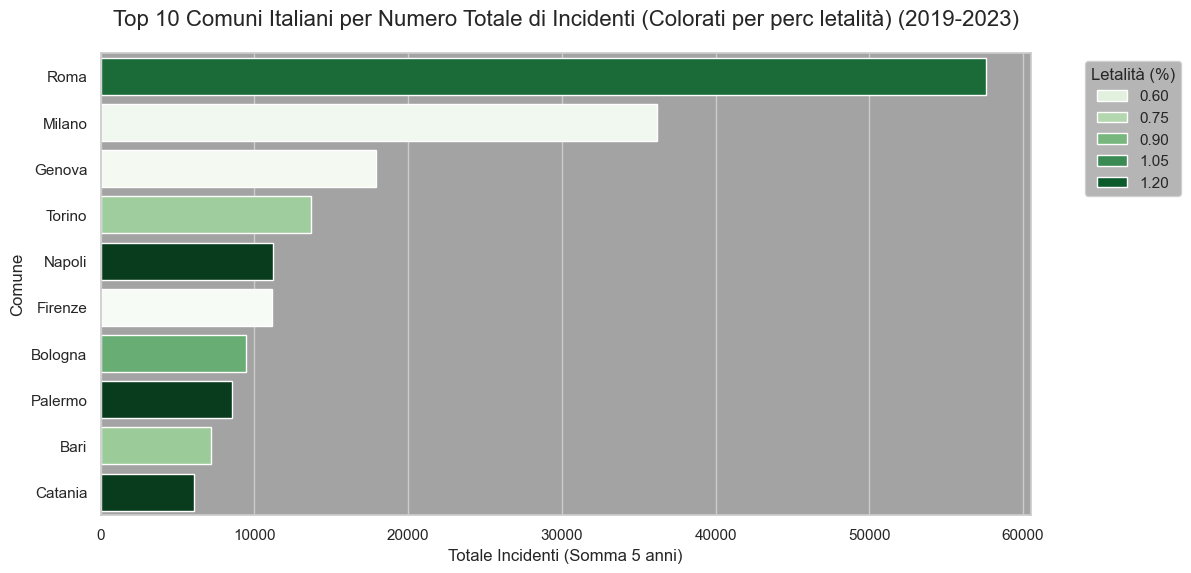

In [12]:
# Qua ho voluto creare una bar chart per una prima analisi grafica.
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#A3A3A3"})
plt.figure(figsize=(12, 6))

barplot = sns.barplot(
    data=top10_assoluta, 
    x='Totale_Incidenti', 
    y='Nome_Comune',
    hue='Indice_Gravita_Perc',
    palette='Greens',
    dodge=False
)

plt.title('Top 10 Comuni Italiani per Numero Totale di Incidenti (Colorati per perc letalità) (2019-2023)', fontsize=16, pad=20)
plt.xlabel('Totale Incidenti (Somma 5 anni)', fontsize=12)
plt.ylabel('Comune', fontsize=12)

# ho voluto sistemare la posizione della legenda.
plt.legend(title='Letalità (%)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [13]:
# TOP TEN DEI COMUNI PER TASSO DI INCIDENTI PROCAPITE.
# Domanda 1: Quali sono i 10 Comuni Italiani in qui ci sono più incidenti per kmq? 
# (escludendo i comuni con meno di 5k abitanti.) (si individua dalla lunghezza della barra.) 
# Domanda 2: Dove un singolo cittadino rischia di più la vita per tasso di incidenti procapite?
# (lo si individua dall'intensità o meno del colore setsso della barra.)
#
# Ho deciso di fare 
# Qua ho voluto prima di tutto fare un filtro per escludere i piccoli comuni.
# Nel primo grafico ho trovato quali erano i comuni in assoluto indipendentemente dalla densità per kmq,
# ma ora lo farò, ma per farlo devo escludere i centri abitati troppo piccoli per evitare outlier
# che si creerebbero per esempio a causa di un singolo incidente in un comune con 100 abitanti.
# La legge dei piccoli numeri Documentazione:
# Ho scelto un filtro di 5k di abitanti perchè è la soglia attuale utilizzata dall'ISTAT per
# distinguere i piccoli comuni dai centri urbani.  
#
#  spiegazione.
soglia_abitanti = 5000
df_grandi_comuni = df_finale[df_finale['Popolazione'] >= soglia_abitanti].copy()

# Raggruppo per comune per calcolare la Media del tasso procapite nei ultimi 5 anni.
top10_relativa = df_grandi_comuni.groupby('Nome_Comune', as_index=False).agg(
    Tasso_Incidenti_10k=('Tasso_Incidenti_10k', 'mean'),
    Totale_Incidenti=('Totale_Incidenti', 'sum'),
    Morti=('Morti', 'sum')
)

# Calcolo l'indice di Gravità.
top10_relativa['Indice_Gravita_Perc'] = (top10_relativa['Morti'] / top10_relativa['Totale_Incidenti']) * 100
top10_relativa['Indice_Gravita_Perc'] = top10_relativa['Indice_Gravita_Perc'].fillna(0).round(2)


# Qua ho ordinato il tasso_incidenti_10k, dal tasso medio più alto al più basso, filtrando i primi 10.
top10_relativa = top10_relativa.sort_values(by='Tasso_Incidenti_10k', ascending=False).head(10)

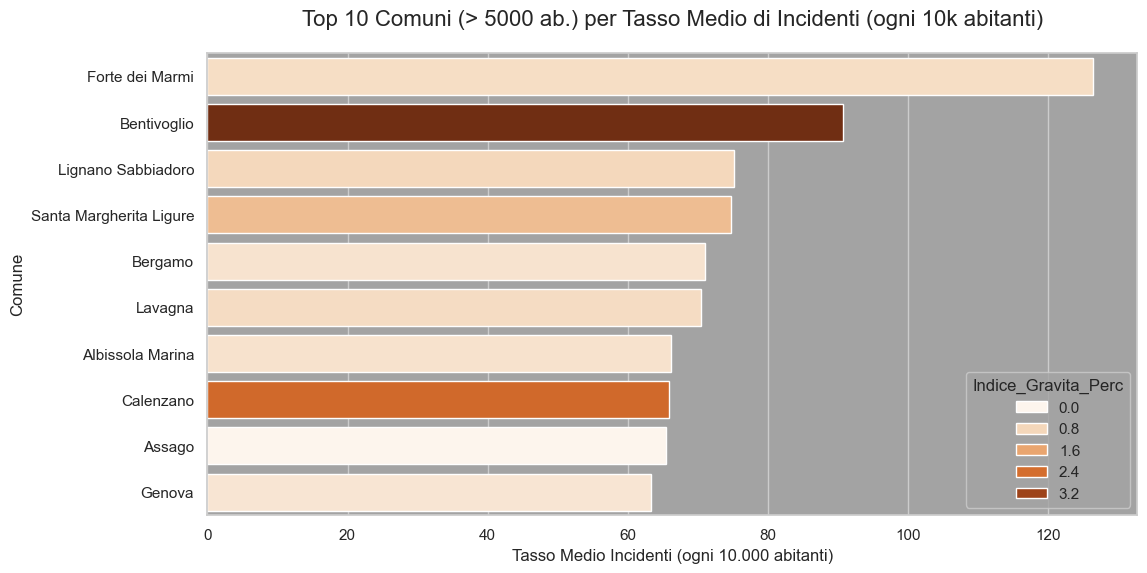

In [14]:
# Stile tabella e tabella.
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#A3A3A3"})
plt.figure(figsize=(12, 6))

barplot = sns.barplot(
    data=top10_relativa, 
    x='Tasso_Incidenti_10k', 
    y='Nome_Comune',
    hue='Indice_Gravita_Perc',
    palette='Oranges',
    dodge=False    
)

plt.title(f'Top 10 Comuni (> {soglia_abitanti} ab.) per Tasso Medio di Incidenti (ogni 10k abitanti)', fontsize=16, pad=20)
plt.xlabel('Tasso Medio Incidenti (ogni 10.000 abitanti)', fontsize=12)
plt.ylabel('Comune', fontsize=12)

plt.show()

In [15]:
# ANALISI DEI RISULTATI

# Forte dei marmi, Lignano Sabbiadoro, Lavagna, Albissola Marina, sono località Turistiche,
# possibile aumento della concentrazione di incidenti.

# Nodi Logistici: Assago, Bentivoglio, Calenzano. Bentivoglio è un outlier perchè visualizzando
# sulle mappe, oltre ad essere un area interporto e anche attraversata dall'autostrada,
# e penso sia dovuto anche alla presenza di un ospedale sempre vicino all'autostrada.

# Città che rimangono comunque congesitionate: Bergamo, Genova.

# --Dubbio se includere nel dataset finale pulito da analissare se inserire anche una colonna
# dove si ha un valore per determinare se sono stati coinvolti solo motociclisti per esempio?--



In [16]:
# Dubbio indice di fatalità.


In [17]:
# Domanda 1: Quali sono i Comuni italiani che rappresentano un'anomalia rispetto alla normalità?
# (per trovare gli outlier)
# Domanda 2: Tra queste anomalie, quali sono le quelle mortali? (lo si individua dall'intensità
# del colore dei pallini).
# Ho fatto delle ricerche per fare lo scatter plot per evitare errorri o sporcizia nei dati, devo
# applicare una Scala Logaritmica per evitare di sovrapporre migliaia di Comuni in un solo punto e
# spostare città grandi come Roma Milano Napoli dall'altro lato del grafico.
# In questo modo i comuni verranno spalmati senza sovrapporsi.

# Grafico 3: Scatter plot


In [18]:
# Aggrego i 5 anni per ogni comune.
df_scatter = df_finale.groupby('Nome_Comune', as_index=False).agg(
    Popolazione=('Popolazione', 'mean'),
    Totale_Incidenti=('Totale_Incidenti', 'sum'),
    Morti=('Morti', 'sum')
)

# Ricalcolo l'indice di fatalità per i 5 anni che sarà utilizzato per il colore.
df_scatter['Indice_Gravita_Perc'] = (df_scatter['Morti'] / df_scatter['Totale_Incidenti']) * 100
df_scatter['Indice_Gravita_Perc'] = df_scatter['Indice_Gravita_Perc'].fillna(0)

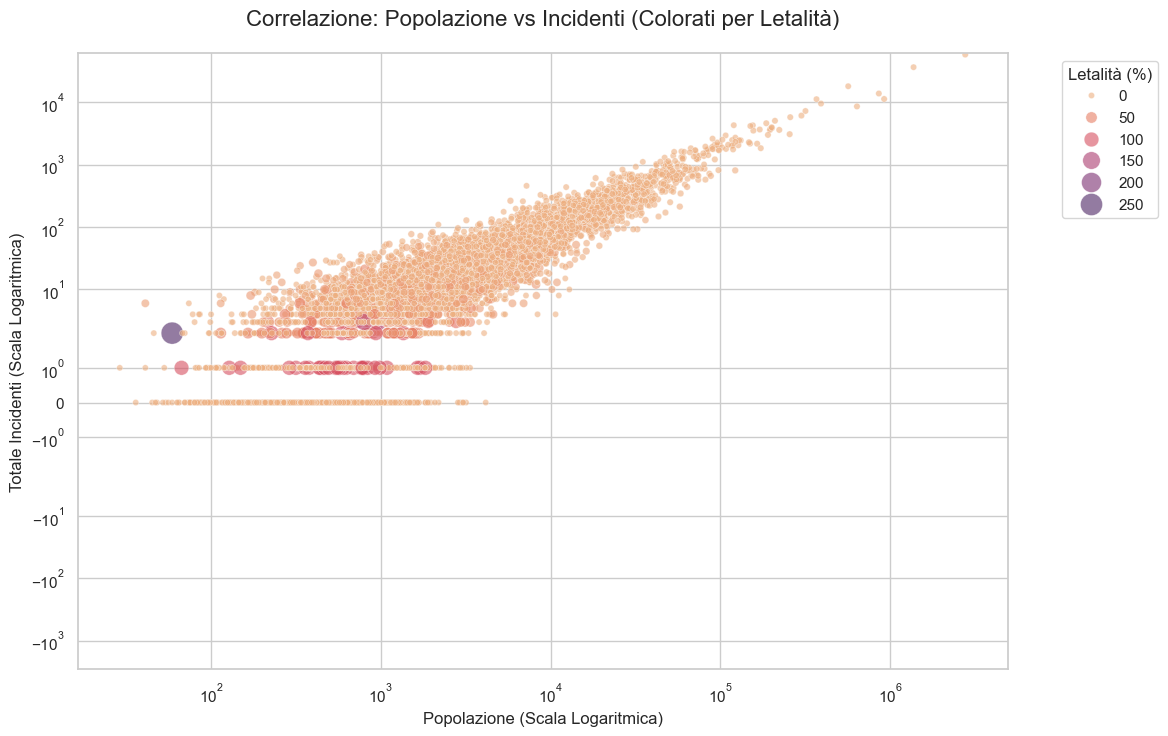

In [19]:
# Adesso creo fisicamente lo scatter plot.
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Faccio i puntini con Seaborn.
scatter = sns.scatterplot(
    data=df_scatter,
    x='Popolazione',
    y='Totale_Incidenti',
    hue='Indice_Gravita_Perc',
    palette='flare',
    alpha=0.6,
    size='Indice_Gravita_Perc',
    sizes=(20, 250)
)

# Applico le scale logaritmiche per rendere leggibile il grafico.
plt.xscale('log')
plt.yscale('symlog')

# Titoli ed etichette.
plt.title('Correlazione: Popolazione vs Incidenti (Colorati per Letalità)', fontsize=16, pad=20)
plt.xlabel('Popolazione (Scala Logaritmica)', fontsize=12)
plt.ylabel('Totale Incidenti (Scala Logaritmica)', fontsize=12)

# Posiziono la legenda.
plt.legend(title='Letalità (%)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()


In [ ]:
# Adesso analizzo con il codice il primo scatter plot per trovare i Comuni Outlier.
outlier_letali = df_scatter.sort_values(by='Indice_Gravita_Perc', ascending=False).head(10)
display(outlier_letali[['Nome_Comune', 'Popolazione', 'Totale_Incidenti', 'Morti', 'Indice_Gravita_Perc']])

,Nome_Comune,Popolazione,Totale_Incidenti,Morti,Indice_Gravita_Perc
1695,Castelmagno,59.0,2,5,250.000000
6851,Spadola,797.0,3,4,133.333333
3831,Marzi,965.0,3,4,133.333333
3465,Lenta,797.0,1,1,100.000000
6365,Sant'Arcangelo Trimonte,493.0,1,1,100.000000
7722,Villamaina,924.0,1,1,100.000000
4137,Montaldo di Mondovì,540.0,1,1,100.000000
4165,Monte Isola,1644.0,1,1,100.000000
437,Azzone,377.0,1,1,100.000000
3544,Locatello,837.0,1,1,100.000000


In [21]:
# Analisi di: Castelmagno (Grave incidente isolato nel 2020, LandRover con 9 persone precipitato,
# in una scarpata, 5 morti.)

# Analisi aggiuntive...

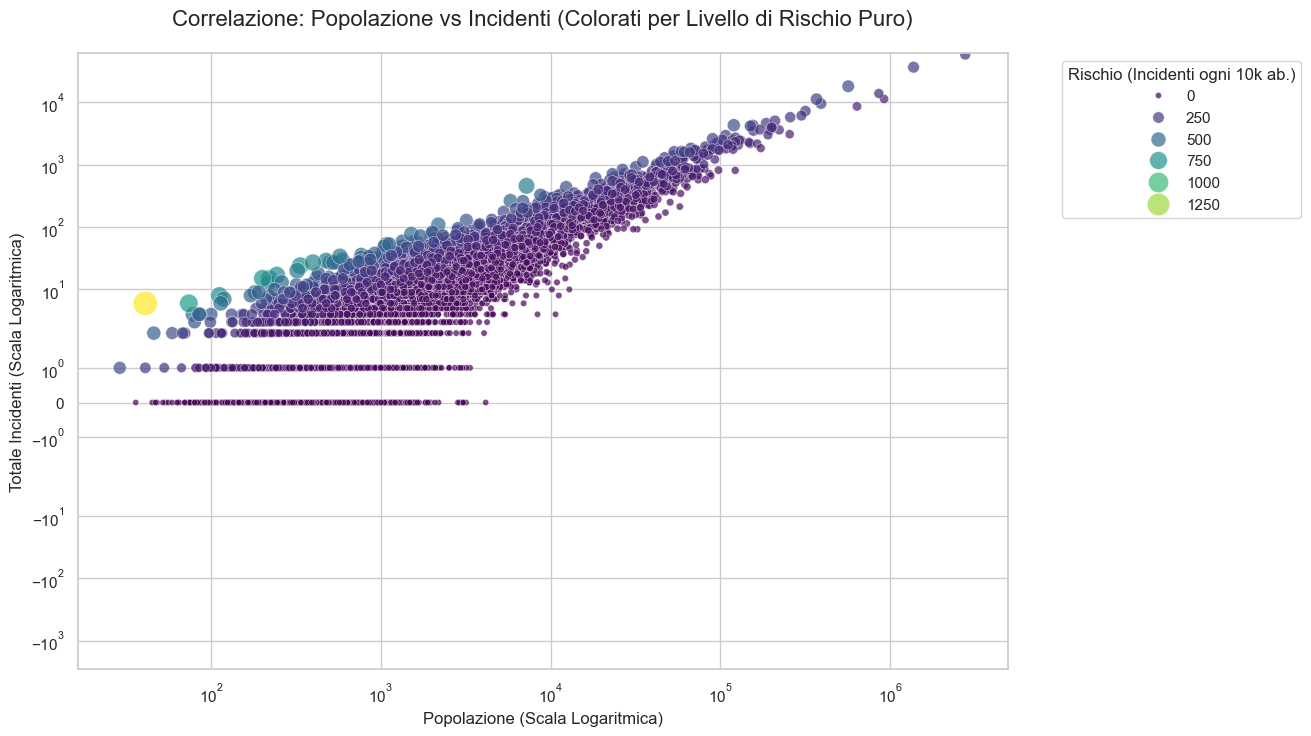

In [25]:
# Scatterplot 2 per trovare le 'Anomalie generali di rischio' escludendo la letalità.
# Questo perchè vorrei cercare outlier da valutare come punto di forza o da scartare,
# per l'azienda. cioè in base se ci sono più incidenti NON letali ci sarà un diverso
# investimento rispetto ad altri.

df_scatter = df_finale.groupby('Nome_Comune', as_index=False).agg(
    Popolazione=('Popolazione', 'mean'),
    Tasso_Incidenti_10k=('Tasso_Incidenti_10k', 'mean'),
    Totale_Incidenti=('Totale_Incidenti', 'sum')
)

# Qua usi i dati aggregati, calcolando il Tasso pro-capite sui totali dei 5 anni per evitare distorsioni.
df_scatter['Tasso_Incidenti_10k'] = (df_scatter['Totale_Incidenti'] / df_scatter['Popolazione']) * 10000

# Scatter Plot "Rischio Generale"
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Creo i punti colorandoli in base al Tasso (quanti incidenti capitano in proporzione)
scatter_rischio = sns.scatterplot(
    data=df_scatter, 
    x='Popolazione', 
    y='Totale_Incidenti', 
    hue='Tasso_Incidenti_10k', # Coloro in base a quanti incidenti ci sono per abitante.
    palette='viridis',                   # Qua ho usato una palette diversa (dal blu al giallo intenso) per distinguerlo dal precedente
    alpha=0.7,
    size='Tasso_Incidenti_10k',# I comuni più pericolosi per i residenti saranno più grandi
    sizes=(20, 300)
)

# Scale Logaritmiche 
plt.xscale('log')
plt.yscale('symlog')

# Titoli ed etichette
plt.title('Correlazione: Popolazione vs Incidenti (Colorati per Livello di Rischio Puro)', fontsize=16, pad=20)
plt.xlabel('Popolazione (Scala Logaritmica)', fontsize=12)
plt.ylabel('Totale Incidenti (Scala Logaritmica)', fontsize=12)

# Legenda
plt.legend(title='Rischio (Incidenti ogni 10k ab.)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [27]:
# Adesso analizzo con il codice il secondo scatter plot per trovare i Comuni Outlier.
outlier_rischio = df_scatter.sort_values(by='Tasso_Incidenti_10k', ascending=False).head(10)
display(outlier_rischio[['Nome_Comune', 'Popolazione', 'Totale_Incidenti', 'Tasso_Incidenti_10k']])

,Nome_Comune,Popolazione,Totale_Incidenti,Tasso_Incidenti_10k
4081,Moncenisio,41.0,6,1463.414634
5091,Pietraporzio,74.0,6,810.810811
5263,Ponte Gardena/Waidbruck,201.0,15,746.268657
912,Brienno,335.0,24,716.417910
519,Bard,112.0,8,714.285714
2617,Exilles,244.0,17,696.721311
489,Balocco,220.0,15,681.818182
7758,Villarboit,398.0,27,678.391960
2831,Forte dei Marmi,7217.0,456,631.841485
2545,Dorio,322.0,20,621.118012


In [ ]:
# Forte dei Marmi rimane un buon comune dove fare investimenti.
# Moncenisio e Pietraporzio sono i classici outlier causati dalla legge dei piccoli numeri.